
# CS1 EXP-0-IDABS — End-to-End Identifier Abstraction + Nested Alpha Study


## 1. Runtime settings

In [ ]:
from pathlib import Path

REPO_URL = "https://github.com/EnomisLP/DiverseVul--IS-Project.git"
REPO_BRANCH = "simo"

WORKSPACE_ROOT = Path.cwd()
REPO_ROOT = WORKSPACE_ROOT / "DiverseVul--IS-Project"
PROJECT_DIR = REPO_ROOT / "vuln-detection"
SRC_DIR = PROJECT_DIR / "src"

DRIVE_ROOT = WORKSPACE_ROOT / "IntelligentSystemProject" / "VulnerabilityDetectionData"
PROCESSED_DIR = DRIVE_ROOT / "processed"
MANIFEST_ROOT = DRIVE_ROOT / "manifests"
OUTPUT_ROOT = DRIVE_ROOT / "outputs"

EXPERIMENT_ID = "cs1_project_holdout20_innercv_v1"
EXPERIMENT_OUTPUT_ROOT = OUTPUT_ROOT / EXPERIMENT_ID

INPUT_PARQUET = PROCESSED_DIR / "rdiversevul_cs1_normalized_v1.parquet"

CODE_COLUMN = "normalized_code"
# CODE_COLUMN = "abstracted_code_v1"

CODE_COLUMN_TAG = "abstracted" if CODE_COLUMN == "abstracted_code_v1" else "normalized"

ABSTRACTED_PARQUET = PROCESSED_DIR / "rdiversevul_cs1_normalized_plus_abstracted_v2.parquet"
ABSTRACTED_SUMMARY_JSON = PROCESSED_DIR / "rdiversevul_cs1_abstracted_v2_summary.json"

OUTER_MANIFEST_PATH = MANIFEST_ROOT / EXPERIMENT_ID / "outer_holdout" / "cs1_outer_project_holdout_manifest.parquet"
INNER_MANIFEST_PATH = MANIFEST_ROOT / EXPERIMENT_ID / "inner_cv" / "cs1_project_grouped_5fold_manifest.parquet"


#IDABS_OUTPUT_DIR = EXPERIMENT_OUTPUT_ROOT / "exp0_idabs_nested_alpha_development_only_v1"
IDABS_OUTPUT_DIR = OUTPUT_ROOT / f"exp0_idabs_nested_alpha_development_only_v2_reproduction_{CODE_COLUMN_TAG}"

BUILD_ABSTRACTED_IF_MISSING = True
RUN_NORMALIZATION_TESTS = True
ABSTRACTION_BATCH_SIZE = 10_000


RUN_IDABS_PROFILE = False
RUN_IDABS_OFFICIAL = True
RESUME_INTERRUPTED_RUN = False


ALPHA_GRID = (1e-6, 3e-6, 1e-5, 3e-5, 1e-4)

print("Settings loaded.")
print("Input parquet:", INPUT_PARQUET)
print("Abstracted parquet:", ABSTRACTED_PARQUET)
print("Output dir:", IDABS_OUTPUT_DIR)


## 2. Fetch repository

In [ ]:
import urllib.request
import zipfile


def download_and_extract_repo(repo_url, branch, target_dir):
    if target_dir.exists():
        print(f"Repository already exists at {target_dir}")
        return

    print(f"Downloading {repo_url} (branch: {branch}) without git...")
    clean_url = repo_url.removesuffix(".git")
    zip_url = f"{clean_url}/archive/refs/heads/{branch}.zip"
    target_dir.parent.mkdir(parents=True, exist_ok=True)
    zip_path = target_dir.parent / f"{target_dir.name}_download_temp.zip"

    urllib.request.urlretrieve(zip_url, zip_path)

    print("Extracting files...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(target_dir.parent)

    repo_name = clean_url.split("/")[-1]
    extracted_folder = target_dir.parent / f"{repo_name}-{branch}"
    if extracted_folder.exists():
        extracted_folder.rename(target_dir)

    zip_path.unlink()
    print(f"Repository ready at {target_dir}")
import sys

download_and_extract_repo(REPO_URL, REPO_BRANCH, REPO_ROOT)

if not PROJECT_DIR.is_dir():
    raise FileNotFoundError(f"Missing project directory: {PROJECT_DIR}")
if not SRC_DIR.is_dir():
    raise FileNotFoundError(f"Missing source directory: {SRC_DIR}")

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("\nRepository ready.")
print("Repo root:", REPO_ROOT)
print("Project dir:", PROJECT_DIR)
print("Source dir:", SRC_DIR)


## 3. Install/import dependencies and verify committed files

In [3]:

import subprocess
import sys

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "numpy", "pandas", "scipy", "scikit-learn", "matplotlib", "pyarrow", "joblib", "pytest"
], check=True)
print("Dependencies installed/verified.")


Dependencies installed/verified.


In [4]:

import json
import time
from datetime import datetime, timezone
from dataclasses import replace

import numpy as np
import pandas as pd

required_repo_files = [
    SRC_DIR / "case_study_1" / "normalization_v3.py",
    SRC_DIR / "case_study_1" / "normalization.py",
    SRC_DIR / "case_study_1" / "exp0" / "exp0_lr.py",
    SRC_DIR / "case_study_1" / "exp0" / "exp0_nested_alpha.py",
]

missing = [str(path) for path in required_repo_files if not path.is_file()]
if missing:
    raise FileNotFoundError("Missing required committed files:\n" + "\n".join(missing))

from case_study_1.normalization_v3 import (
    ABSTRACTION_VERSION,
    NORMALIZATION_VERSION,
    abstract_identifiers,
    representation_summary,
)
from case_study_1 import split_manifest
from case_study_1.exp0.exp0_lr import Exp0Config
from case_study_1.exp0.exp0_nested_alpha import (
    NestedAlphaConfig,
    run_exp0_nested_inner_profile,
    run_exp0_nested_alpha,
)

print("Imported project modules successfully.")
print("NORMALIZATION_VERSION:", NORMALIZATION_VERSION)
print("ABSTRACTION_VERSION:", ABSTRACTION_VERSION)


Imported project modules successfully.
NORMALIZATION_VERSION: cs1-conservative-v3-no-nfkc
ABSTRACTION_VERSION: cs1-identifier-abstraction-v1


In [5]:


from pathlib import Path

test_file = PROJECT_DIR / "tests" / "test_normalization_v3.py"

text = test_file.read_text(encoding="utf-8")

text = text.replace(
    "from normalization_v3 import",
    "from case_study_1.normalization_v3 import",
)

test_file.write_text(text, encoding="utf-8")

print("Patched:", test_file)
print(test_file.read_text(encoding="utf-8").splitlines()[:10])

Patched: /content/DiverseVul--IS-Project/vuln-detection/tests/test_normalization_v3.py
['import pytest', 'import pandas as pd', '', 'from case_study_1.normalization_v3 import (', '    normalize_code,', '    abstract_identifiers,', '    add_abstracted_code_column,', '    _normalize_line_endings_and_unicode,', '    iter_cpp_lexical_tokens,', ')']


## 4. Optional: run normalization v3 tests

In [6]:


import os
import subprocess
import sys
from pathlib import Path

if RUN_NORMALIZATION_TESTS:
    test_file = PROJECT_DIR / "tests" / "test_normalization_v3.py"

    if not test_file.is_file():
        print("Test file not found, skipping:", test_file)
    else:
        env = os.environ.copy()
        env["PYTHONPATH"] = str(SRC_DIR) + os.pathsep + env.get("PYTHONPATH", "")

        command = [
            sys.executable,
            "-m",
            "pytest",
            str(test_file),
            "-q",
            "-s",
        ]

        print("$", " ".join(str(x) for x in command))
        print("PYTHONPATH:", env["PYTHONPATH"])

        result = subprocess.run(
            command,
            cwd=str(PROJECT_DIR),
            env=env,
            text=True,
            capture_output=True,
        )

        print("\n--- pytest stdout ---")
        print(result.stdout)

        print("\n--- pytest stderr ---")
        print(result.stderr)

        if result.returncode != 0:
            raise RuntimeError(
                f"normalization_v3 tests failed with return code {result.returncode}"
            )

        print("normalization_v3 tests passed.")
else:
    print("RUN_NORMALIZATION_TESTS=False, skipping tests.")

$ /usr/bin/python3 -m pytest /content/DiverseVul--IS-Project/vuln-detection/tests/test_normalization_v3.py -q -s
PYTHONPATH: /content/DiverseVul--IS-Project/vuln-detection/src:/env/python

--- pytest stdout ---
........
8 passed in 1.10s


--- pytest stderr ---

normalization_v3 tests passed.


## 5. Build `abstracted_code_v1` cached parquet if missing

In [7]:


if not INPUT_PARQUET.is_file():
    raise FileNotFoundError(f"Missing input parquet: {INPUT_PARQUET}")

if ABSTRACTED_PARQUET.exists():
    print("Abstracted parquet already exists. Reusing cached file:")
    print(" ", ABSTRACTED_PARQUET)
elif not BUILD_ABSTRACTED_IF_MISSING:
    raise FileNotFoundError(
        f"Abstracted parquet is missing and BUILD_ABSTRACTED_IF_MISSING=False:\n{ABSTRACTED_PARQUET}"
    )
else:
    start = time.perf_counter()
    print("Loading normalized dataset:", INPUT_PARQUET)
    df = pd.read_parquet(INPUT_PARQUET)

    required_columns = {"source_row_id", "normalized_code", "label", "project"}
    missing_columns = required_columns.difference(df.columns)
    if missing_columns:
        raise KeyError(f"Input dataset missing required columns: {sorted(missing_columns)}")
    if "abstracted_code_v1" in df.columns:
        raise RuntimeError("Input dataset unexpectedly already contains abstracted_code_v1.")

    print(f"Rows: {len(df):,}")
    print(f"Building abstracted_code_v1 in batches of {ABSTRACTION_BATCH_SIZE:,}...")

    abstracted_chunks = []
    n_rows = len(df)
    for start_idx in range(0, n_rows, ABSTRACTION_BATCH_SIZE):
        end_idx = min(start_idx + ABSTRACTION_BATCH_SIZE, n_rows)
        batch_start = time.perf_counter()
        chunk = df["normalized_code"].iloc[start_idx:end_idx].map(abstract_identifiers)
        abstracted_chunks.append(chunk)
        batch_minutes = (time.perf_counter() - batch_start) / 60
        print(
            f"  abstracted rows {start_idx:,}–{end_idx - 1:,} "
            f"({end_idx:,}/{n_rows:,}) in {batch_minutes:.2f} min",
            flush=True,
        )

    df["abstracted_code_v1"] = pd.concat(abstracted_chunks).sort_index()


    if len(df["abstracted_code_v1"]) != len(df):
        raise RuntimeError("abstracted_code_v1 length mismatch.")
    if df["abstracted_code_v1"].isna().any():
        raise RuntimeError("abstracted_code_v1 contains NA values.")
    empty_rate = (df["abstracted_code_v1"].astype(str).str.len() == 0).mean()
    if empty_rate > 0.01:
        raise RuntimeError(f"Unexpectedly high empty abstracted_code_v1 rate: {empty_rate:.4f}")

    print("Saving:", ABSTRACTED_PARQUET)
    df.to_parquet(ABSTRACTED_PARQUET, index=False)

    summary = {
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "abstraction_version": ABSTRACTION_VERSION,
        "normalization_version": NORMALIZATION_VERSION,
        "input_path": str(INPUT_PARQUET),
        "output_path": str(ABSTRACTED_PARQUET),
        "rows": int(len(df)),
        "source_id_unique": bool(df["source_row_id"].is_unique),
        "normalized_code": representation_summary(df["normalized_code"]),
        "abstracted_code_v1": representation_summary(df["abstracted_code_v1"]),
        "runtime_minutes": float((time.perf_counter() - start) / 60),
    }
    with ABSTRACTED_SUMMARY_JSON.open("w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    print("Saved:", ABSTRACTED_PARQUET)
    print("Saved:", ABSTRACTED_SUMMARY_JSON)
    print(json.dumps(summary, indent=2)[:4000])


Abstracted parquet already exists. Reusing cached file:
  /content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/processed/rdiversevul_cs1_normalized_plus_abstracted_v1.parquet


## 6. Load abstracted dataset and frozen manifests

In [8]:

if not ABSTRACTED_PARQUET.is_file():
    raise FileNotFoundError(f"Missing abstracted parquet: {ABSTRACTED_PARQUET}")
if not OUTER_MANIFEST_PATH.is_file():
    raise FileNotFoundError(f"Missing outer manifest: {OUTER_MANIFEST_PATH}")
if not INNER_MANIFEST_PATH.is_file():
    raise FileNotFoundError(f"Missing inner manifest: {INNER_MANIFEST_PATH}")

full_df = pd.read_parquet(ABSTRACTED_PARQUET)
outer_manifest_df = pd.read_parquet(OUTER_MANIFEST_PATH)
inner_manifest_df = split_manifest.load_manifest(
    INNER_MANIFEST_PATH,
    config=split_manifest.SplitConfig(n_splits=5, random_state=42, shuffle=True),
)

required_full_columns = {
    "source_row_id", "code", "normalized_code", "abstracted_code_v1", "label", "project"
}
missing_full = required_full_columns.difference(full_df.columns)
if missing_full:
    raise KeyError(f"Abstracted dataset missing columns: {sorted(missing_full)}")

print("Full abstracted dataset:", full_df.shape)
print("Outer manifest:", outer_manifest_df.shape)
print("Inner manifest:", inner_manifest_df.shape)
print("Partitions:")
print(outer_manifest_df["partition"].value_counts(dropna=False))


Full abstracted dataset: (261667, 6)
Outer manifest: (261667, 5)
Inner manifest: (203958, 4)
Partitions:
partition
development      203958
outer_holdout     57709
Name: count, dtype: int64


## 7. Strict manifest and development-only validation

In [9]:


expected_outer_columns = {"source_row_id", "label", "project", "partition"}
missing_outer = expected_outer_columns.difference(outer_manifest_df.columns)
if missing_outer:
    raise KeyError(f"Outer manifest missing columns: {sorted(missing_outer)}")


for name, frame in [
    ("full_df", full_df),
    ("outer_manifest_df", outer_manifest_df),
    ("inner_manifest_df", inner_manifest_df),
]:
    if frame["source_row_id"].duplicated().any():
        raise RuntimeError(f"{name} contains duplicate source_row_id values.")

full_indexed = full_df.set_index("source_row_id", drop=False)
outer_ids = set(outer_manifest_df["source_row_id"].tolist())
if not outer_ids.issubset(set(full_indexed.index)):
    raise RuntimeError("Outer manifest contains IDs not present in abstracted dataset.")


outer_join = outer_manifest_df.set_index("source_row_id").join(
    full_indexed[["label", "project"]],
    rsuffix="_dataset",
)
if not (outer_join["label"].astype(int) == outer_join["label_dataset"].astype(int)).all():
    raise RuntimeError("Label mismatch between abstracted dataset and outer manifest.")
if not (outer_join["project"].astype(str) == outer_join["project_dataset"].astype(str)).all():
    raise RuntimeError("Project mismatch between abstracted dataset and outer manifest.")

dev_ids = set(outer_manifest_df.loc[outer_manifest_df["partition"] == "development", "source_row_id"].tolist())
holdout_ids = set(outer_manifest_df.loc[outer_manifest_df["partition"] == "outer_holdout", "source_row_id"].tolist())
inner_ids = set(inner_manifest_df["source_row_id"].tolist())

if not dev_ids:
    raise RuntimeError("No development IDs found in outer manifest.")
if not holdout_ids:
    raise RuntimeError("No outer_holdout IDs found in outer manifest.")
if dev_ids.intersection(holdout_ids):
    raise RuntimeError("Development and outer holdout ID overlap detected.")
if inner_ids != dev_ids:
    raise RuntimeError(
        f"Inner CV manifest IDs must exactly equal development IDs. "
        f"Missing={len(dev_ids - inner_ids)}, extra={len(inner_ids - dev_ids)}"
    )

dev_projects = set(outer_manifest_df.loc[outer_manifest_df["partition"] == "development", "project"].astype(str))
holdout_projects = set(outer_manifest_df.loc[outer_manifest_df["partition"] == "outer_holdout", "project"].astype(str))
project_overlap = dev_projects.intersection(holdout_projects)
if project_overlap:
    raise RuntimeError(f"Development/holdout project overlap detected: {sorted(project_overlap)[:10]}")


development_frame = full_indexed.loc[list(dev_ids)].copy().reset_index(drop=True)
if set(development_frame["source_row_id"]).intersection(holdout_ids):
    raise RuntimeError("Global holdout rows leaked into development_frame.")


development_frame = development_frame[
    ["source_row_id", "abstracted_code_v1", "normalized_code", "label", "project"]
].copy()

summary_rows = []
for name, ids in [("full_manifest", outer_ids), ("development", dev_ids), ("outer_holdout", holdout_ids)]:
    temp = full_indexed.loc[list(ids)]
    summary_rows.append({
        "partition": name,
        "rows": int(len(temp)),
        "projects": int(temp["project"].astype(str).nunique()),
        "vulnerable": int(temp["label"].astype(int).sum()),
        "positive_rate": float(temp["label"].astype(int).mean()),
    })

split_summary_df = pd.DataFrame(summary_rows)
display(split_summary_df)

print("Validation complete: using development partition only.")
print("Development rows:", f"{len(development_frame):,}")
print("Global holdout rows excluded:", f"{len(holdout_ids):,}")


,partition,rows,projects,vulnerable,positive_rate
0,full_manifest,261667,797,13938,0.053266
1,development,203958,594,10727,0.052594
2,outer_holdout,57709,203,3211,0.055641


Validation complete: using development partition only.
Development rows: 203,958
Global holdout rows excluded: 57,709


## 8. Configure EXP-0-IDABS nested alpha experiment

In [ ]:

base_config = Exp0Config(
    experiment_name="cs1_exp0_idabs_nested_alpha",
    code_column=CODE_COLUMN,
    source_id_column="source_row_id",
    label_column="label",
    project_column="project",
    fold_column="fold",
    n_splits=5,
    random_state=42,
    decision_threshold=0.50,
    word_ngram_range=(1, 3),
    word_min_df=3,
    word_max_df=0.995,
    word_max_features=50_000,
    char_analyzer="char",
    char_ngram_range=(3, 4),
    char_min_df=8,
    char_max_df=0.995,
    char_max_features=60_000,
    lowercase=False,
    sublinear_tf=True,
    tfidf_norm="l2",
    sgd_loss="log_loss",
    sgd_penalty="l2",
    sgd_alpha=1e-5,
    sgd_class_weight="balanced",
    sgd_max_iter=80,
    sgd_tol=1e-3,
    sgd_average=True,
    top_features_per_direction=0,
    verbose=False,
)

nested_config = NestedAlphaConfig(
    experiment_name="cs1_exp0_idabs_nested_alpha_dev_grouped",
    alpha_grid=tuple(ALPHA_GRID),
    inner_n_splits=3,
    inner_random_state=20260707,
    selection_metric="average_precision_pr_auc",
    decision_threshold=0.50,
    tie_break_rule="higher_alpha_then_grid_order",
    top_features_per_direction=0,
    verbose=True,
)

print("Base config code column:", base_config.code_column)
print("Alpha grid:", nested_config.alpha_grid)
print("Output directory:", IDABS_OUTPUT_DIR)


## 9. Optional profile run — inner tuning only, no outer-development scoring

In [11]:

if RUN_IDABS_PROFILE:
    profile = run_exp0_nested_inner_profile(
        development_frame=development_frame,
        development_manifest=inner_manifest_df,
        outer_fold_id=4,
        base_config=base_config,
        nested_config=nested_config,
    )
    print("Profile duration minutes:", profile["total_profile_seconds"] / 60)
    print("Selected alpha:")
    display(pd.DataFrame([profile["selected_alpha"]]))
    print("Inner alpha summary:")
    display(profile["alpha_summary"])
    print("Inner split audit:")
    display(profile["inner_split_audit"])
else:
    print("RUN_IDABS_PROFILE=False; skipping profile.")


RUN_IDABS_PROFILE=False; skipping profile.


## 10. Official development-only nested run

In [ ]:
import pandas as pd

EMPTY_ABSTRACTED_SENTINEL = "EMPTY_ABSTRACTED_CODE_SAMPLE"

development_frame = development_frame.copy()

development_frame[CODE_COLUMN] = (
    development_frame[CODE_COLUMN]
    .fillna("")
    .astype(str)
)

empty_abstracted_mask = development_frame[CODE_COLUMN].str.strip().eq("")
n_empty_abstracted = int(empty_abstracted_mask.sum())

print(f"Empty {CODE_COLUMN} rows in development partition:", n_empty_abstracted)

if n_empty_abstracted:
    columns_to_show = [
        "source_row_id",
        "label",
        "project",
        "normalized_code",
        CODE_COLUMN,
    ]
    available_columns = [c for c in columns_to_show if c in development_frame.columns]

    preview = development_frame.loc[empty_abstracted_mask, available_columns].copy()

    if "normalized_code" in preview.columns:
        preview["normalized_code_preview"] = (
            preview["normalized_code"]
            .fillna("")
            .astype(str)
            .str.slice(0, 500)
        )

    display(preview)

    development_frame.loc[empty_abstracted_mask, CODE_COLUMN] = EMPTY_ABSTRACTED_SENTINEL

    print(
        f"Replaced {n_empty_abstracted} empty abstracted rows with "
        f"sentinel token: {EMPTY_ABSTRACTED_SENTINEL}"
    )

assert not development_frame[CODE_COLUMN].str.strip().eq("").any()

print("Non-empty abstracted-code guard passed.")

In [17]:

if RUN_IDABS_OFFICIAL:
    results = run_exp0_nested_alpha(
        development_frame=development_frame,
        development_manifest=inner_manifest_df,
        base_config=base_config,
        nested_config=nested_config,
        output_dir=IDABS_OUTPUT_DIR,
        resume=RESUME_INTERRUPTED_RUN,
        additional_metadata={
            "run_kind": "identifier_abstraction_nested_alpha_development_only",
            "global_outer_holdout_used": False,
            "input_parquet": str(ABSTRACTED_PARQUET),
            "input_column": "abstracted_code_v1",
            "abstraction_version": ABSTRACTION_VERSION,
            "normalization_version": NORMALIZATION_VERSION,
            "outer_manifest_path": str(OUTER_MANIFEST_PATH),
            "inner_manifest_path": str(INNER_MANIFEST_PATH),
            "repo_commit": subprocess.check_output([
                "git", "-C", str(REPO_ROOT), "rev-parse", "HEAD"
            ]).decode().strip(),
            "note": "Supplementary development-only representation study; does not reopen final holdout model selection.",
        },
    )
    print("\nOfficial EXP-0-IDABS nested run complete.")
else:
    results = None
    print("RUN_IDABS_OFFICIAL=False; official training skipped.")


[11:08:36] Nested EXP-0 alpha study started: 5 outer-development folds, 3 inner project-grouped folds, alpha grid=[1e-06, 3e-06, 1e-05, 3e-05, 0.0001].
[11:08:36] Scope: development partition only. The global 20% outer holdout is not loaded or scored.
[11:08:36] Outer development fold 1/5 | inner tuning started (3-fold project-grouped CV; 5 alpha values).
[11:08:37] Outer development fold 1/5, inner fold 1/3 | vectorizing once for all alpha candidates...
[11:11:14] Outer development fold 1/5, inner fold 1/3 | vectorization done in 2.61 min (107,017 features).
[11:11:56] Outer development fold 1/5, inner fold 2/3 | vectorizing once for all alpha candidates...
[11:14:27] Outer development fold 1/5, inner fold 2/3 | vectorization done in 2.52 min (103,721 features).
[11:15:08] Outer development fold 1/5, inner fold 3/3 | vectorizing once for all alpha candidates...
[11:17:41] Outer development fold 1/5, inner fold 3/3 | vectorization done in 2.54 min (110,000 features).
[11:18:26] Outer d

## 11. Display result summary

In [18]:

if results is None:
    print("No official results object in memory. Set RUN_IDABS_OFFICIAL=True or load saved artifacts manually.")
else:
    pooled = results["evaluation"]["pooled_metrics"]
    fold_metrics = results["evaluation"]["fold_metrics"]
    selected = results["selected_alpha"]
    outer_training = results["outer_fold_training"]

    pooled_df = pd.DataFrame([{"metric": k, "value": v} for k, v in pooled.items()])
    print("Pooled nested OOF metrics:")
    display(pooled_df)

    print("Selected alpha by frozen outer-development fold:")
    display(selected)

    print("Fold metrics:")
    display(fold_metrics)

    print("Outer fold training / leakage audit:")
    display(outer_training)

    print("Artifacts:")
    artifacts = results.get("artifacts")
    print(artifacts)


Pooled nested OOF metrics:


,metric,value
0,n_samples,203958.000000
1,vulnerable_1,10727.000000
2,non_vulnerable_0,193231.000000
3,positive_rate,0.052594
4,threshold,0.500000
5,average_precision_pr_auc,0.136888
6,precision,0.110501
7,recall,0.568659
8,f1,0.185045
9,mcc,0.158030


Selected alpha by frozen outer-development fold:


,outer_fold,selected_alpha,selected_inner_pooled_pr_auc,selected_inner_mean_fold_pr_auc,selection_metric,tie_break_rule,total_inner_vectorization_seconds,outer_train_rows,outer_train_projects,alpha_grid,inner_n_splits
0,0,0.0001,0.150710,0.151465,average_precision_pr_auc,higher_alpha_then_grid_order,459.834029,148449,593,1e-06;3e-06;1e-05;3e-05;0.0001,3
1,1,0.0001,0.136875,0.136926,average_precision_pr_auc,higher_alpha_then_grid_order,465.280224,163167,436,1e-06;3e-06;1e-05;3e-05;0.0001,3
2,2,0.0001,0.129878,0.133300,average_precision_pr_auc,higher_alpha_then_grid_order,469.378362,164886,448,1e-06;3e-06;1e-05;3e-05;0.0001,3
3,3,0.0001,0.131655,0.133334,average_precision_pr_auc,higher_alpha_then_grid_order,471.529466,168942,457,1e-06;3e-06;1e-05;3e-05;0.0001,3
4,4,0.0001,0.124944,0.137516,average_precision_pr_auc,higher_alpha_then_grid_order,485.931694,170388,442,1e-06;3e-06;1e-05;3e-05;0.0001,3


Fold metrics:


,fold,n_samples,vulnerable_1,non_vulnerable_0,positive_rate,threshold,average_precision_pr_auc,precision,recall,f1,...,negative_predictive_value,false_positive_rate,false_negative_rate,true_negative,false_positive,false_negative,true_positive,predicted_positive,predicted_positive_rate,test_unique_projects
0,0,55509,2420,53089,0.043597,0.5,0.100563,0.094230,0.435950,0.154965,...,0.969196,0.191019,0.564050,42948,10141,1365,1055,11196,0.201697,1
1,1,40791,2091,38700,0.051261,0.5,0.138631,0.112092,0.594931,0.188642,...,0.971475,0.254625,0.405069,28846,9854,847,1244,11098,0.272070,158
2,2,39072,2062,37010,0.052774,0.5,0.126830,0.109402,0.613967,0.185712,...,0.971055,0.278465,0.386033,26704,10306,796,1266,11572,0.296171,146
3,3,35016,2047,32969,0.058459,0.5,0.167947,0.118499,0.599902,0.197905,...,0.966779,0.277078,0.400098,23834,9135,819,1228,10363,0.295950,137
4,4,33570,2107,31463,0.062764,0.5,0.155749,0.119100,0.620313,0.199832,...,0.964596,0.307250,0.379687,21796,9667,800,1307,10974,0.326899,152


Outer fold training / leakage audit:


,outer_fold,selected_alpha,outer_train_rows,outer_test_rows,outer_train_vulnerable,outer_test_vulnerable,outer_train_positive_rate,outer_test_positive_rate,outer_train_projects,outer_test_projects,...,test_matrix_density,model_fit_seconds,prediction_seconds,model_n_iter,convergence_warning_count,convergence_warning_messages,outer_total_fold_seconds,outer_score_min,outer_score_max,outer_score_mean
0,0,0.0001,148449,55509,8307,2420,0.055959,0.043597,593,1,...,0.004797,8.257492,0.067062,12,0,,206.345742,0.026033,0.920891,0.345265
1,1,0.0001,163167,40791,8636,2091,0.052927,0.051261,436,158,...,0.004698,9.079578,0.100533,14,0,,205.447839,0.022612,0.928897,0.378803
2,2,0.0001,164886,39072,8665,2062,0.052551,0.052774,448,146,...,0.004840,10.344929,0.049067,14,0,,206.952737,0.017625,0.936137,0.397125
3,3,0.0001,168942,35016,8680,2047,0.051379,0.058459,457,137,...,0.005152,13.702954,0.048061,19,0,,221.651675,0.021654,0.952894,0.396171
4,4,0.0001,170388,33570,8620,2107,0.050590,0.062764,442,152,...,0.005217,8.999979,0.045691,13,0,,204.379691,0.025986,0.947802,0.411545


Artifacts:
NestedAlphaArtifacts(nested_config_json=PosixPath('/content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/outputs/exp0_idabs_nested_alpha_development_only_v2_reproduction/cs1_exp0_idabs_nested_alpha_dev_grouped_nested_config.json'), inner_alpha_scores_csv=PosixPath('/content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/outputs/exp0_idabs_nested_alpha_development_only_v2_reproduction/cs1_exp0_idabs_nested_alpha_dev_grouped_inner_alpha_scores.csv'), selected_alpha_csv=PosixPath('/content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/outputs/exp0_idabs_nested_alpha_development_only_v2_reproduction/cs1_exp0_idabs_nested_alpha_dev_grouped_selected_alpha_per_outer_fold.csv'), inner_split_audit_csv=PosixPath('/content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/outputs/exp0_idabs_nested_alpha_development_only_v2_reproduction/cs1_exp0_idabs_nested_alpha_dev_grouped_inner_split_audit.csv'), outer_fold_

## 11b. Confidence interval on development-CV pooled PR-AUC

In [19]:
import case_study_1.confidence_intervals as confidence_intervals

exp0_idabs_devcv_ci = confidence_intervals.bootstrap_metric_ci(
    results["oof_predictions"],
    metric="average_precision_pr_auc",
    n_bootstrap=1000,
    random_state=42,
)
print(confidence_intervals.format_ci_report(exp0_idabs_devcv_ci))

average_precision_pr_auc: point estimate = 0.1369
  95% CI (project-block bootstrap): [0.1184, 0.1617]
  valid resamples: 1000/1000 (0 degenerate, dropped)
  n_projects: 594, random_state=42
  Reflects sampling variability within this dataset only; not an estimate of generalization to C functions outside this collection.


## 12. Compare against previous development-only reference results

In [20]:


reference_rows = [
    {
        "experiment": "EXP-0 fixed normalized_code",
        "scope": "development pooled OOF",
        "input_column": "normalized_code",
        "tuning": "none; alpha=1e-5 fixed",
        "pr_auc": 0.125205,
    },
    {
        "experiment": "EXP-0 nested-alpha normalized_code",
        "scope": "development nested pooled OOF",
        "input_column": "normalized_code",
        "tuning": "inner project-CV alpha selection",
        "pr_auc": 0.141971,
    },
    {
        "experiment": "EXP-2 MLP fixed representation",
        "scope": "development pooled OOF",
        "input_column": "SVD(TF-IDF normalized_code)+static",
        "tuning": "inner validation for epoch/threshold",
        "pr_auc": 0.138157,
    },
]

if results is not None:
    reference_rows.append({
        "experiment": "EXP-0-IDABS nested-alpha abstracted_code_v1",
        "scope": "development nested pooled OOF",
        "input_column": "abstracted_code_v1",
        "tuning": "inner project-CV alpha selection",
        "pr_auc": float(results["evaluation"]["pooled_metrics"]["average_precision_pr_auc"]),
    })

comparison_df = pd.DataFrame(reference_rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)
display(comparison_df)


,experiment,scope,input_column,tuning,pr_auc
0,EXP-0 nested-alpha normalized_code,development nested pooled OOF,normalized_code,inner project-CV alpha selection,0.141971
1,EXP-2 MLP fixed representation,development pooled OOF,SVD(TF-IDF normalized_code)+static,inner validation for epoch/threshold,0.138157
2,EXP-0-IDABS nested-alpha abstracted_code_v1,development nested pooled OOF,abstracted_code_v1,inner project-CV alpha selection,0.136888
3,EXP-0 fixed normalized_code,development pooled OOF,normalized_code,none; alpha=1e-5 fixed,0.125205


## 13. Canonical Retraining: Fit Optimal Model on Complete Development Set

In [21]:
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
import joblib
import pandas as pd
import numpy as np

word_vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.995,
    max_features=50000,
    sublinear_tf=True,
    lowercase=False
)
char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 4),
    min_df=8,
    max_df=0.995,
    max_features=60000,
    sublinear_tf=True,
    lowercase=False
)

X_dev_word = word_vectorizer.fit_transform(development_frame['abstracted_code_v1'])
X_dev_char = char_vectorizer.fit_transform(development_frame['abstracted_code_v1'])
X_dev_full = sp.hstack([X_dev_word, X_dev_char], format='csr')
y_dev = development_frame['label'].values.astype(int)

if results is not None and "selected_alpha" in results:
    optimal_alpha = results["selected_alpha"]["selected_alpha"].mode()[0]
else:
    optimal_alpha = 1e-4

final_sgd_model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=optimal_alpha,
    class_weight="balanced",
    random_state=42,
    max_iter=80,
    tol=1e-3,
    average=True
)
final_sgd_model.fit(X_dev_full, y_dev)

IDABS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(final_sgd_model, IDABS_OUTPUT_DIR / "final_exp0_lr_model.joblib")
joblib.dump(word_vectorizer, IDABS_OUTPUT_DIR / "final_word_vectorizer.joblib")
joblib.dump(char_vectorizer, IDABS_OUTPUT_DIR / "final_char_vectorizer.joblib")

['/content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/outputs/exp0_idabs_nested_alpha_development_only_v2_reproduction/final_char_vectorizer.joblib']

## 14. Final Evaluation: Score Frozen 20% Outer Holdout Partition

Pooled Out-of-Fold Evaluation
                   n_samples: 57709
                vulnerable_1: 3211
            non_vulnerable_0: 54498
               positive_rate: 0.055641
                   threshold: 0.500000
    average_precision_pr_auc: 0.145765
                   precision: 0.114068
                      recall: 0.579259
                          f1: 0.190603
                         mcc: 0.159958
                 specificity: 0.734926
         false_positive_rate: 0.265074
               true_negative: 40052
              false_positive: 14446
              false_negative: 1351
               true_positive: 1860


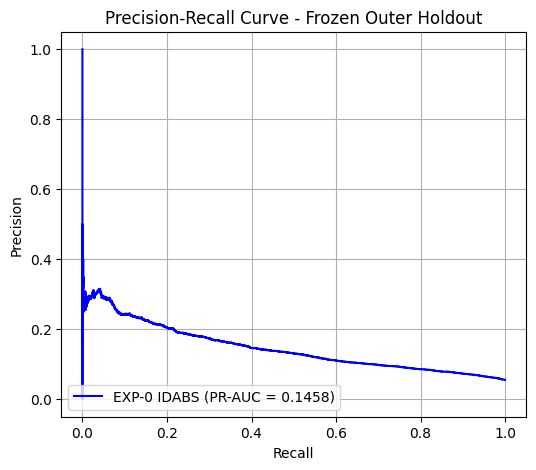

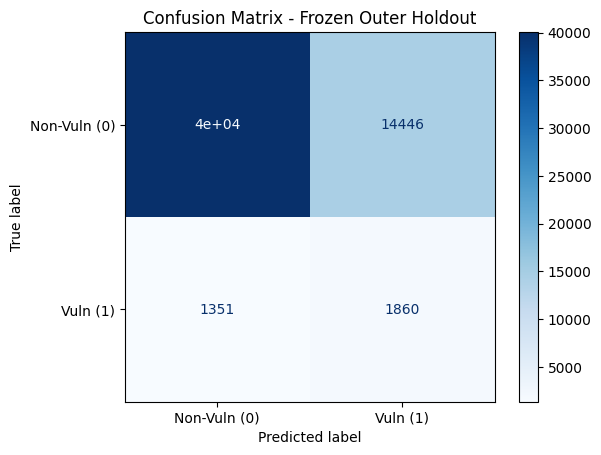

In [22]:
import case_study_1.evaluation as evaluation
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay

full_indexed = full_df.set_index("source_row_id", drop=False)
holdout_frame = full_indexed.loc[list(holdout_ids)].copy().reset_index(drop=True)

holdout_frame['abstracted_code_v1'] = holdout_frame['abstracted_code_v1'].fillna("").astype(str)
empty_holdout_mask = holdout_frame['abstracted_code_v1'].str.strip().eq("")
if empty_holdout_mask.any():
    holdout_frame.loc[empty_holdout_mask, 'abstracted_code_v1'] = "EMPTY_ABSTRACTED_CODE_SAMPLE"

X_holdout_word = word_vectorizer.transform(holdout_frame['abstracted_code_v1'])
X_holdout_char = char_vectorizer.transform(holdout_frame['abstracted_code_v1'])
X_holdout_full = sp.hstack([X_holdout_word, X_holdout_char], format='csr')

y_holdout = holdout_frame['label'].values.astype(int)
holdout_projects = holdout_frame['project'].values

y_holdout_scores = final_sgd_model.predict_proba(X_holdout_full)[:, 1]

holdout_predictions_df = pd.DataFrame({
    "source_row_id": holdout_frame['source_row_id'].values,
    "project": holdout_projects,
    "label": y_holdout,
    "y_score": y_holdout_scores,
    "fold": 0
})

holdout_predictions_df["fold"] = 0
holdout_metrics = evaluation.evaluate_oof_predictions(
    holdout_predictions_df,
    config=evaluation.EvaluationConfig(threshold=0.50, expected_n_folds=1),
)

print(evaluation.format_metric_report(holdout_metrics["pooled_metrics"]))
holdout_predictions_df.to_csv(IDABS_OUTPUT_DIR / "exp0_holdout_predictions.csv", index=False)

precision, recall, _ = precision_recall_curve(y_holdout, y_holdout_scores)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='b', label=f'EXP-0 IDABS (PR-AUC = {holdout_metrics["pooled_metrics"]["average_precision_pr_auc"]:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Frozen Outer Holdout')
plt.legend(loc="lower left")
plt.grid(True)
plt.savefig(IDABS_OUTPUT_DIR / "outer_holdout_pr_curve.png")
plt.show()

cm = confusion_matrix(y_holdout, (y_holdout_scores >= 0.50).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Vuln (0)", "Vuln (1)"])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Frozen Outer Holdout')
plt.savefig(IDABS_OUTPUT_DIR / "outer_holdout_confusion_matrix.png")
plt.show()

## 14b. Confidence interval on outer-holdout PR-AUC

In [23]:
import case_study_1.confidence_intervals as confidence_intervals

exp0_idabs_holdout_ci = confidence_intervals.bootstrap_metric_ci(
    holdout_predictions_df,
    metric="average_precision_pr_auc",
    n_bootstrap=1000,
    random_state=42,
)
print(confidence_intervals.format_ci_report(exp0_idabs_holdout_ci))

average_precision_pr_auc: point estimate = 0.1458
  95% CI (project-block bootstrap): [0.1230, 0.1730]
  valid resamples: 1000/1000 (0 degenerate, dropped)
  n_projects: 203, random_state=42
  Reflects sampling variability within this dataset only; not an estimate of generalization to C functions outside this collection.


## 15. Interpretability Audit: Extract Global Feature Weights

In [24]:
word_feature_names = word_vectorizer.get_feature_names_out()
char_feature_names = char_vectorizer.get_feature_names_out()
all_feature_names = np.concatenate([word_feature_names, char_feature_names])
coefficients = final_sgd_model.coef_[0]

feature_importances = pd.DataFrame({
    'feature': all_feature_names,
    'weight': coefficients
}).sort_values(by='weight', ascending=False).reset_index(drop=True)

print("Top 15 Predictors of Vulnerable Code:")
display(feature_importances.head(15))

print("\nTop 15 Predictors of Clean Code:")
display(feature_importances.tail(15))

feature_importances.to_csv(IDABS_OUTPUT_DIR / "exp0_feature_weights.csv", index=False)

Top 15 Predictors of Vulnerable Code:


,feature,weight
0,VAR2 STR_LITERAL,1.043457
1,O1 V,0.974056
2,FUNC1 STR_LITERAL STR_LITERAL,0.958307
3,);\nc,0.934647
4,int FUNC1 int,0.932630
5,sprintf VAR3 STR_LITERAL,0.919995
6,sprintf VAR3,0.910199
7,MACRO1 VAR1 MACRO1,0.872008
8,1(,0.834482
9,C1(,0.826191



Top 15 Predictors of Clean Code:


,feature,weight
109985,void return,-0.595858
109986,R2(,-0.600989
109987,AR2(,-0.600989
109988,) c,-0.611800
109989,()\n{,-0.623642
109990,) co,-0.634531
109991,R5 *,-0.636440
109992,VAR2,-0.657925
109993,return return,-0.662802
109994,ret,-0.683611


## 16. Error Analysis: Isolate Holdout False Positives & False Negatives

In [25]:
holdout_res = holdout_frame.copy()
holdout_res['y_score'] = y_holdout_scores
holdout_res['y_pred'] = (y_holdout_scores >= 0.50).astype(int)

false_positives = holdout_res[(holdout_res['label'] == 0) & (holdout_res['y_pred'] == 1)]
false_negatives = holdout_res[(holdout_res['label'] == 1) & (holdout_res['y_pred'] == 0)]

print(f"Extracted {len(false_positives)} False Positives and {len(false_negatives)} False Negatives.")

false_positives[['source_row_id', 'project', 'y_score', 'code']].sample(n=min(5, len(false_positives)), random_state=42).to_csv(IDABS_OUTPUT_DIR / "sample_false_positives.csv", index=False)
false_negatives[['source_row_id', 'project', 'y_score', 'code']].sample(n=min(5, len(false_negatives)), random_state=42).to_csv(IDABS_OUTPUT_DIR / "sample_false_negatives.csv", index=False)

Extracted 14446 False Positives and 1351 False Negatives.
